# Practice 03 — ML Models

A tour of the classical models in scikit-learn: first a classification problem, then a regression one.

The point is not any single model.
**Every scikit-learn estimator has the same four-step interface**, so switching between them changes one
line.

| Step | Code |
|:---|:---|
| Build | `model = Estimator(hyperparameters)` |
| Train | `model.fit(X_train, y_train)` |
| Predict | `y_pred = model.predict(X_test)` |
| Score | `accuracy_score(y_test, y_pred)` |

| Task | Models |
|:---|:---|
| Classification | Logistic Regression, KNN, SVM, Decision Tree, Random Forest, XGBoost |
| Regression | KNN, SVM, Decision Tree, Random Forest, XGBoost |

Random Forest and XGBoost are **ensembles**: the forest averages trees grown on random subsets (*bagging*),
XGBoost adds trees one at a time, each correcting the last (*boosting*).

---
## Step 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor

np.random.seed(42)
plt.rcParams['axes.unicode_minus'] = False

---
## Step 1. Data — Iris

Three species of iris, four measurements each, 150 samples.
The task is to predict the species.

In [2]:
iris = load_iris()

iris_frame = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_frame['label'] = iris.target

print(f'data  : {iris.data.shape}')
print(f'target: {iris.target.shape}, classes {np.unique(iris.target)} ({", ".join(iris.target_names)})')
print(f'samples per class: {np.bincount(iris.target)}')

display(iris_frame.head(10))

data  : (150, 4)
target: (150,), classes [0 1 2] (setosa, versicolor, virginica)
samples per class: [50 50 50]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


---
## Step 2. Split, then Scale

**Split first.** A scaler fitted on the whole dataset leaks test information into training and inflates
every later score.
`stratify=y` keeps class proportions in both parts.

$$x_i^{\text{new}} = \frac{x_i - \mu_i}{\sigma_i}$$

**The guard.** A feature that is constant in training has $\sigma_i = 0$; setting it to 1 leaves it as a
plain difference from the mean.
`1e-8` instead would divide a test sample that *does* move there by almost nothing, handing the model an
input of order $10^{8}$ — no error, just bad predictions.

In [3]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42, stratify=iris.target)

print(f'train: {X_train_raw.shape}, test: {X_test_raw.shape}')
print(f'train class counts: {np.bincount(y_train)}')
print(f'test  class counts: {np.bincount(y_test)}')
print()
print(f'raw    - train mean {X_train_raw.mean(axis=0).round(3)}, std {X_train_raw.std(axis=0).round(3)}')

# standardization: the statistics come from the training set only
train_mean = X_train_raw.mean(axis=0)
train_std  = X_train_raw.std(axis=0)
train_std[train_std == 0] = 1.0     # a feature that is constant in train stays unscaled

X_train = (X_train_raw - train_mean) / train_std
X_test  = (X_test_raw  - train_mean) / train_std   # train statistics, never the test ones

print(f'scaled - train mean {X_train.mean(axis=0).round(3)}, std {X_train.std(axis=0).round(3)}')
print(f'scaled - test  mean {X_test.mean(axis=0).round(3)}, std {X_test.std(axis=0).round(3)}')

train: (120, 4), test: (30, 4)
train class counts: [40 40 40]
test  class counts: [10 10 10]

raw    - train mean [5.842 3.048 3.77  1.205], std [0.837 0.447 1.761 0.759]
scaled - train mean [-0. -0.  0.  0.], std [1. 1. 1. 1.]
scaled - test  mean [ 0.01   0.101 -0.034 -0.037], std [0.925 0.849 0.995 1.001]


The same four lines are available as library objects.

| Scaler in `sklearn.preprocessing` | Effect |
|:---|:---|
| `StandardScaler` | mean 0, variance 1 — same guard as the code above |
| `MinMaxScaler` | rescale to $[0, 1]$; sensitive to outliers |
| `MaxAbsScaler` | rescale by the largest absolute value; keeps sparsity |
| `RobustScaler` | median and interquartile range; least affected by outliers |

All are used as `fit_transform(X_train)` then `transform(X_test)` — never `fit_transform` twice.

The test set does not land at exactly mean 0 and standard deviation 1, and that is correct: its own
statistics were never used.
Seeing exactly 0 and 1 there would be the warning sign.

The unscaled arrays stay as `X_train_raw` / `X_test_raw` — needed below to check against the library and to
feed a pipeline that scales internally.

### The same thing with `StandardScaler`

`fit` stores the column means in `mean_` and the standard deviations in `scale_`; `transform` subtracts and
divides.
It uses the population standard deviation, which is also `numpy.std`'s default, so the two agree to the last
digit.
Printed side by side — nothing to assert.

In [4]:
scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train_raw)   # fit on train
X_test_scaler  = scaler.transform(X_test_raw)        # apply to test, no refit

print('statistics')
print(f'  manual train_mean : {train_mean.round(6)}')
print(f'  scaler.mean_      : {scaler.mean_.round(6)}')
print(f'  manual train_std  : {train_std.round(6)}')
print(f'  scaler.scale_     : {scaler.scale_.round(6)}')
print()
print('first training row')
print(f'  manual : {X_train[0].round(6)}')
print(f'  scaler : {X_train_scaler[0].round(6)}')
print()
print('first test row')
print(f'  manual : {X_test[0].round(6)}')
print(f'  scaler : {X_test_scaler[0].round(6)}')

statistics
  manual train_mean : [5.841667 3.048333 3.77     1.205   ]
  scaler.mean_      : [5.841667 3.048333 3.77     1.205   ]
  manual train_std  : [0.837415 0.446651 1.761136 0.759479]
  scaler.scale_     : [0.837415 0.446651 1.761136 0.759479]

first training row
  manual : [-1.721568 -0.332101 -1.345722 -1.323276]
  scaler : [-1.721568 -0.332101 -1.345722 -1.323276]

first test row
  manual : [-1.721568 -0.108213 -1.402504 -1.323276]
  scaler : [-1.721568 -0.108213 -1.402504 -1.323276]


Identical.
The manual version is kept in the rest of this notebook because the formula stays visible in the code, but
`StandardScaler` is what appears in most scikit-learn code — and it becomes the better choice as soon as the
scaling has to happen inside a pipeline or a cross-validation loop, which is the next step.

---
## Step 3. The Four-Step Flow — Logistic Regression

One model, written out in full, so the four steps are visible before they get wrapped in a loop.

In [5]:
# 1. build
model_logistic = LogisticRegression(random_state=42, max_iter=1000)

# 2. train
model_logistic.fit(X_train, y_train)

# 3. predict
y_pred_logistic = model_logistic.predict(X_test)

# 4. score
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

print(f'coefficients (one row per class):\n{model_logistic.coef_.round(3)}')
print(f'intercepts: {model_logistic.intercept_.round(3)}')
print()
print(f'y_pred: {y_pred_logistic}')
print(f'y_test: {y_test}')
print()
print(f'accuracy: {accuracy_logistic:.4f}')

coefficients (one row per class):
[[-1.089  1.024 -1.799 -1.686]
 [ 0.536 -0.36  -0.204 -0.808]
 [ 0.553 -0.664  2.003  2.494]]
intercepts: [-0.306  1.909 -1.603]

y_pred: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]
y_test: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]

accuracy: 0.9333


---
## Step 4. Chaining the Steps — `Pipeline`

Above, the ordering was our responsibility: fit the scaler on train, transform test.
Calling `fit_transform` on the test set is a one-word slip that raises no error and inflates every score.

A `Pipeline` applies that rule itself:

- `fit(X_train_raw, y_train)` — fits the scaler, transforms, fits the model
- `predict(X_test_raw)` — **transforms only**, no refit

It takes the **raw** input; handing it scaled data would scale twice.
Inside cross-validation each fold then gets its own scaler statistics automatically.

In [6]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(random_state=42, max_iter=1000)),
])

pipeline.fit(X_train_raw, y_train)                 # raw input: the pipeline scales internally
y_pred_pipeline = pipeline.predict(X_test_raw)
accuracy_pipeline = accuracy_score(y_test, y_pred_pipeline)

print(pipeline)
print()
print(f'accuracy - scaled by hand, then fitted : {accuracy_logistic:.4f}')
print(f'accuracy - pipeline on raw input       : {accuracy_pipeline:.4f}')
print()
print(f'the fitted scaler inside the pipeline : {pipeline.named_steps["scaler"].mean_.round(6)}')
print(f'the statistics computed by hand       : {train_mean.round(6)}')

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

accuracy - scaled by hand, then fitted : 0.9333
accuracy - pipeline on raw input       : 0.9333

the fitted scaler inside the pipeline : [5.841667 3.048333 3.77     1.205   ]
the statistics computed by hand       : [5.841667 3.048333 3.77     1.205   ]


Same accuracy, same statistics — the pipeline did what we did by hand, with the ordering built in rather
than remembered.

---
## Step 5. Six Classifiers, One Interface

Each model on its own line so its hyperparameters are visible, all left at scikit-learn defaults.
`random_state` is fixed wherever a model uses randomness.
Fitting and scoring is then the same three lines for every one of them.

In [7]:
model_logistic      = LogisticRegression(random_state=42, max_iter=1000)
model_knn           = KNeighborsClassifier()
model_svm           = SVC(random_state=42)
model_decision_tree = DecisionTreeClassifier(random_state=42)
model_random_forest = RandomForestClassifier(random_state=42)
model_xgboost       = XGBClassifier(random_state=42)

classifiers = {
    'Logistic Regression': model_logistic,
    'KNN':                 model_knn,
    'SVM':                 model_svm,
    'Decision Tree':       model_decision_tree,
    'Random Forest':       model_random_forest,
    'XGBoost':             model_xgboost,
}

for name, model in classifiers.items():
    print(f'{name:20s} -> {type(model).__name__}')

Logistic Regression  -> LogisticRegression
KNN                  -> KNeighborsClassifier
SVM                  -> SVC
Decision Tree        -> DecisionTreeClassifier
Random Forest        -> RandomForestClassifier
XGBoost              -> XGBClassifier


In [8]:
rows = []
for name, model in classifiers.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rows.append({'model': name, 'accuracy': accuracy_score(y_test, y_pred)})

results_classification = pd.DataFrame(rows)
display(results_classification)

,model,accuracy
0,Logistic Regression,0.933333
1,KNN,0.933333
2,SVM,0.966667
3,Decision Tree,0.933333
4,Random Forest,0.900000
5,XGBoost,0.933333


**Read the table carefully.** The test set holds 30 samples, so one misclassified flower moves accuracy by
3.3 points.
The gaps here are one or two samples wide — not evidence that one algorithm beats another.
Separating them would need a larger test set or cross-validation.

What it does show: six very different algorithms, at defaults, all land around 90–97%, and swapping one for
another took a single line.

---
## Step 6. Feature Importance

A fitted Random Forest reports how much each feature contributed to reducing impurity across all of its
trees, in `feature_importances_`.
The values sum to 1.

This is one of the reasons tree ensembles stay popular: the fitted model says something about the data, not
only about the prediction.

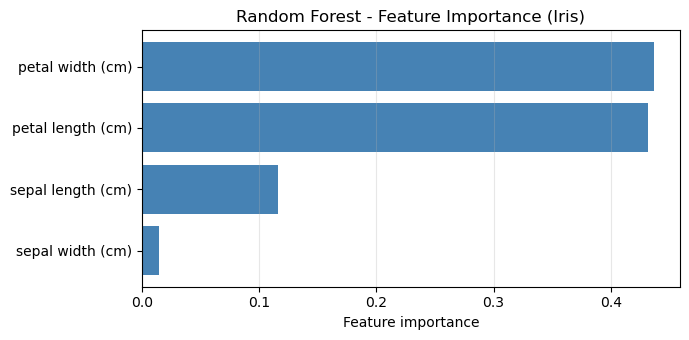

petal width (cm)     0.437
petal length (cm)    0.431
sepal length (cm)    0.116
sepal width (cm)     0.015


In [9]:
importances = model_random_forest.feature_importances_
feature_names = np.array(iris.feature_names)
order = np.argsort(importances)      # ascending, so barh draws the largest bar at the top

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(feature_names[order], importances[order], color='steelblue')
ax.set_xlabel('Feature importance')
ax.set_title('Random Forest - Feature Importance (Iris)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

for index in order[::-1]:
    print(f'{feature_names[index]:<20s} {importances[index]:.3f}')

The two petal measurements carry almost all of the signal, and sepal width carries almost none — which
matches how separable the species look when plotted against petal length and petal width.

---
## Step 7. Regression — Same Flow, Different Estimators

The target is continuous now, so the classes end in `Regressor` and the metric changes.
Nothing else does.

`diabetes`: ten measurements for 442 patients, target is disease progression a year later.
Its features arrive already standardised, so no scaler here.

In [10]:
diabetes = load_diabetes()

diabetes_frame = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
diabetes_frame['target'] = diabetes.target

print(f'data  : {diabetes.data.shape}')
print(f'target: range {diabetes.target.min():.0f} to {diabetes.target.max():.0f}, mean {diabetes.target.mean():.1f}')
print(f'feature mean {diabetes.data.mean(axis=0).round(3)}')

display(diabetes_frame.head(10))

data  : (442, 10)
target: range 25 to 346, mean 152.1
feature mean [-0.  0. -0. -0. -0.  0. -0. -0.  0.  0.]


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346,97.0
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357,138.0
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064,63.0
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349,110.0
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504,310.0


In [11]:
X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(
    diabetes.data, diabetes.target, test_size=0.2, random_state=42)

print(f'train: {X_train_diabetes.shape}, test: {X_test_diabetes.shape}')

train: (353, 10), test: (89, 10)


### Metrics

$$\text{RMSE} = \sqrt{\tfrac{1}{N}\textstyle\sum_n (\hat{y}_n - y_n)^2}, \qquad
R^2 = 1 - \frac{\sum_n (\hat{y}_n - y_n)^2}{\sum_n (\bar{y} - y_n)^2}$$

RMSE is in the units of the target.
$R^2$ is the fraction of variance explained: 1 is perfect, 0 is the score of always predicting the mean.

In [12]:
regressor_knn           = KNeighborsRegressor()
regressor_svm           = SVR()
regressor_decision_tree = DecisionTreeRegressor(random_state=42)
regressor_random_forest = RandomForestRegressor(random_state=42)
regressor_xgboost       = XGBRegressor(random_state=42)

regressors = {
    'KNN':           regressor_knn,
    'SVM':           regressor_svm,
    'Decision Tree': regressor_decision_tree,
    'Random Forest': regressor_random_forest,
    'XGBoost':       regressor_xgboost,
}

rows = []
for name, model in regressors.items():
    model.fit(X_train_diabetes, y_train_diabetes)
    y_pred = model.predict(X_test_diabetes)
    rows.append({'model': name,
                 'RMSE': np.sqrt(mean_squared_error(y_test_diabetes, y_pred)),
                 'R2':   r2_score(y_test_diabetes, y_pred)})

results_regression = pd.DataFrame(rows)
display(results_regression)

,model,RMSE,R2
0,KNN,54.946115,0.430164
1,SVM,65.827699,0.182114
2,Decision Tree,70.546423,0.060654
3,Random Forest,54.332408,0.442823
4,XGBoost,57.887837,0.367515


Two results worth pausing on.

- The **single Decision Tree** scores far below the ensembles.
  Grown to full depth it fits the training data exactly and carries that noise into its predictions;
  averaging many such trees removes it.
- **SVM** does poorly for a mechanical reason: `SVR` defaults to `epsilon=0.1` and `C=1.0`, sensible when
  the target is of order 1.
  This target runs from 25 to 346, so the model is heavily constrained.
  A default is only a default.

---
## Step 8. Predicted vs. True

For regression, the plot to draw is predictions against true values.
Points on the diagonal are exact predictions; the vertical spread around it is the error.

Random Forest is shown because it has the highest $R^2$ on this split.

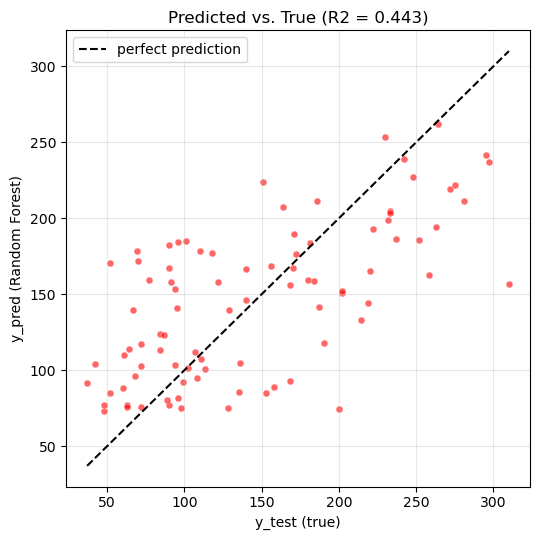

In [13]:
y_pred_random_forest = regressor_random_forest.predict(X_test_diabetes)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_test_diabetes, y_pred_random_forest, c='r', s=25, alpha=0.6, edgecolors='white', linewidths=0.5)
low  = min(y_test_diabetes.min(), y_pred_random_forest.min())
high = max(y_test_diabetes.max(), y_pred_random_forest.max())
ax.plot([low, high], [low, high], 'k--', linewidth=1.5, label='perfect prediction')
ax.set_xlabel('y_test (true)')
ax.set_ylabel('y_pred (Random Forest)')
ax.set_title(f'Predicted vs. True (R2 = {r2_score(y_test_diabetes, y_pred_random_forest):.3f})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The cloud tilts along the diagonal, so the model has captured a real trend, but it is wide — an $R^2$ below
0.5 means more than half of the variance is still unexplained.
Ten physiological measurements are simply not enough to predict disease progression precisely.

---
## Summary

| | Classification | Regression |
|:---|:---|:---|
| Target | class label | continuous value |
| Estimator suffix | `...Classifier` | `...Regressor` |
| Metric | `accuracy_score` | `mean_squared_error`, `r2_score` |
| Typical plot | decision regions, confusion matrix | predicted vs. true |

1. **One interface.** `fit` / `predict` is the same call for a linear model, a neighbour lookup and a
   forest of a hundred trees.
2. **Split before you scale**, and let a pipeline enforce it.
3. **Defaults are a starting point**, and thirty test samples cannot separate 93% from 97%.